<a href="https://colab.research.google.com/github/madhuraspatil/AIML_Practicle/blob/main/Regression_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Details

* **Name**: Harshini Ramdas Bhandary
* **PRN**: 202401040151
* **Roll No**: 35
* **Division**: A (Batch: A2)

---

### Title: Evaluating Regression Models for House Price Prediction

### AIM:
This project focuses on building a Linear Regression model from scratch using Gradient Descent to predict housing prices. We will explore how different optimization settings affect our results and compare our custom model against Scikit-Learn's built-in regression.

### Objectives:
1. Analyze real-world housing data to see how different features relate to home values.
2. Clean and preprocess the data (handling missing data, scaling features, splitting into training/testing sets).
3. Code a Gradient Descent algorithm from scratch to optimize model parameters.
4. Study how changing the learning rate and the number of training iterations affects model convergence.
5. Evaluate models using metrics like Mean Absolute Error (MAE) and Mean Squared Error (MSE).
6. Compare our custom implementation side-by-side with Scikit-learn's model.
7. Create clear visualizations like convergence history, actual-vs-predicted plots, and residual plots to analyze error patterns.
8. Understand the practical limits and challenges of using basic linear regression on complex real-world datasets.

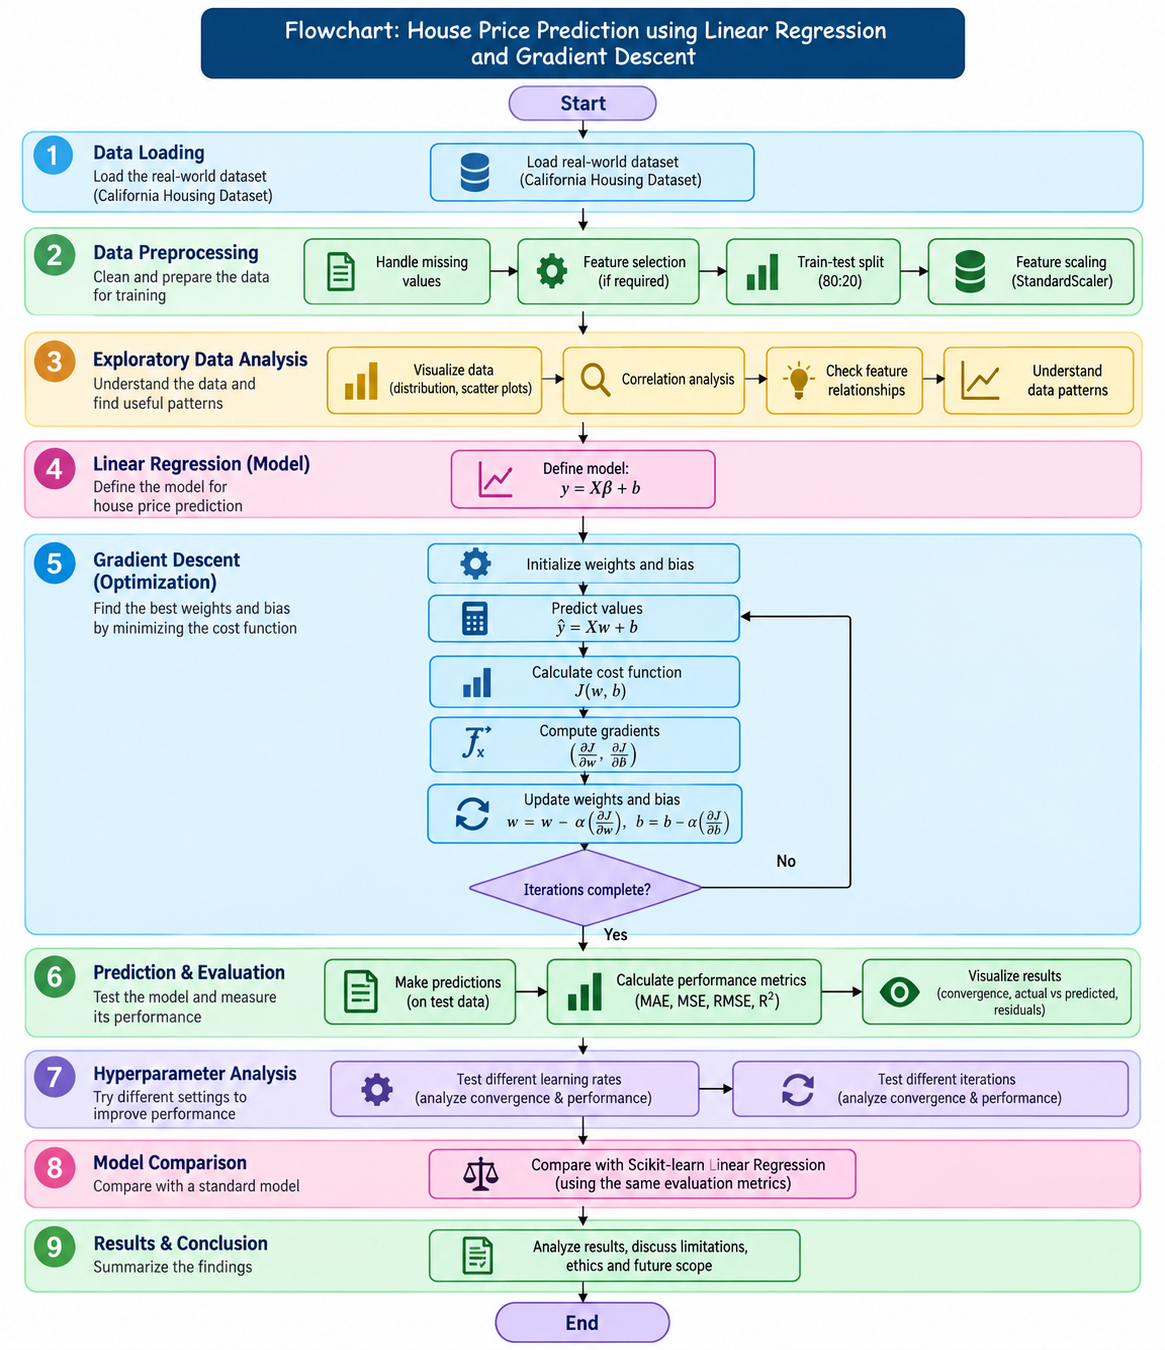

Libraries loaded successfully!

Dataset loaded successfully!
Number of rows: 20640
Number of features: 8

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25



Feature names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Missing values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

Statistical summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


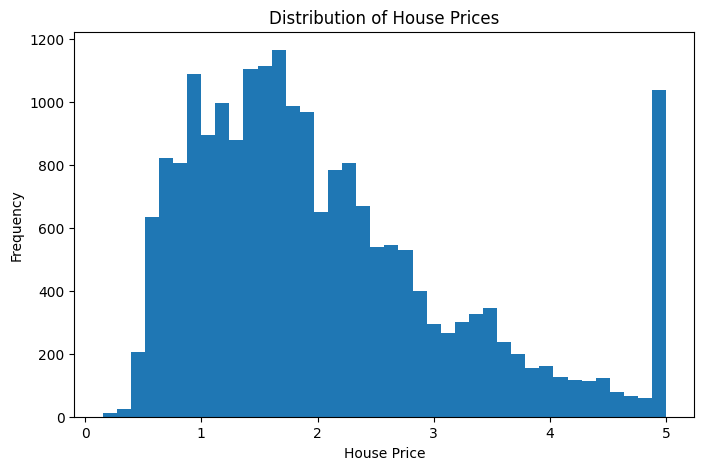


Correlation with House Price:
HousePrice    1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: HousePrice, dtype: float64


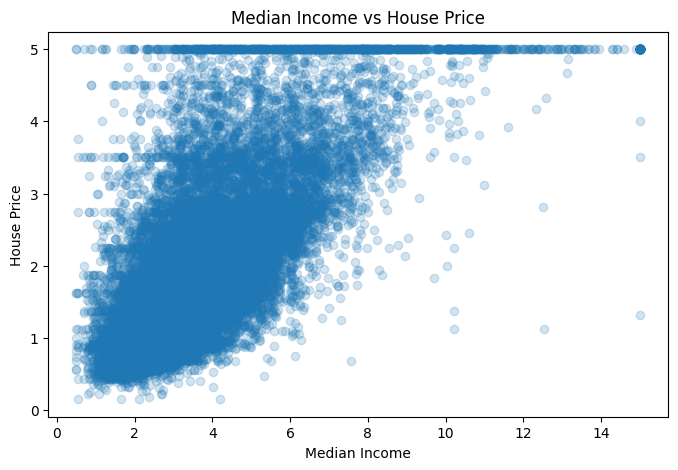


Training samples: 16512
Testing samples: 4128

Feature scaling completed!

Gradient Descent training completed!

GRADIENT DESCENT RESULTS
MAE : 0.5477
MSE : 0.5672


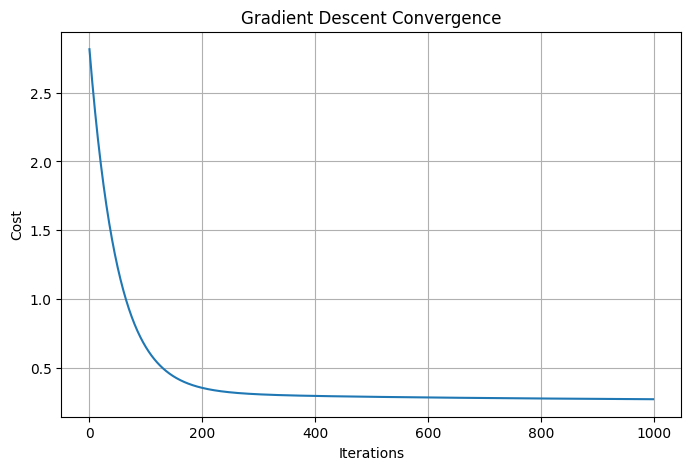

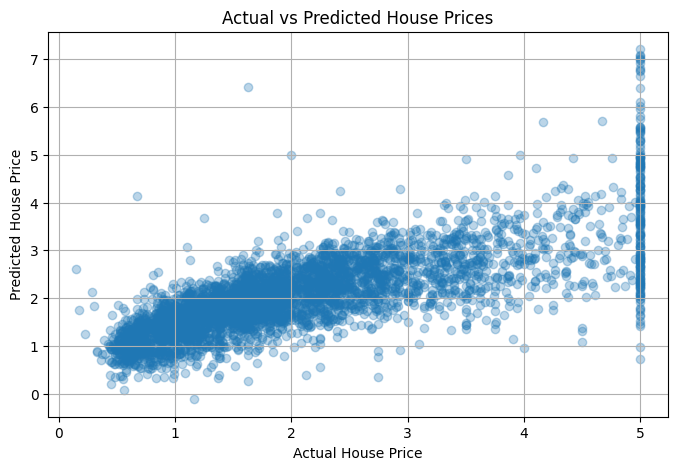

KeyboardInterrupt: 

In [3]:
# ============================================================
# HOUSE PRICE PREDICTION USING LINEAR REGRESSION
# AND GRADIENT DESCENT
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Configure display options so pandas and numpy display fully
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)
np.set_printoptions(threshold=np.inf)

print("Libraries loaded successfully!")


# ============================================================
# 2. LOAD REAL HOUSE PRICE DATASET
# ============================================================

housing = fetch_california_housing()

X = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

y = pd.Series(
    housing.target,
    name="HousePrice"
)

print("\nDataset loaded successfully!")
print("Number of rows:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nFirst 5 rows:")
display(X.head())


# ============================================================
# 3. DATASET INFORMATION
# ============================================================

print("\nFeature names:")
print(X.columns.tolist())

print("\nMissing values:")
print(X.isnull().sum())

print("\nStatistical summary:")
display(X.describe())


# ============================================================
# 4. EXPLORATORY DATA ANALYSIS
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(y, bins=40)

plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")

plt.show()


# ============================================================
# 5. CORRELATION ANALYSIS
# ============================================================

data = X.copy()
data["HousePrice"] = y

correlation = data.corr()["HousePrice"].sort_values(
    ascending=False
)

print("\nCorrelation with House Price:")
print(correlation)


# ============================================================
# 6. MEDIAN INCOME VS HOUSE PRICE
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    X["MedInc"],
    y,
    alpha=0.2
)

plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Median Income vs House Price")

plt.show()


# ============================================================
# 7. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ============================================================
# 8. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed!")


# ============================================================
# 9. GRADIENT DESCENT FUNCTION
# ============================================================

def gradient_descent(X, y, learning_rate, iterations):

    m = len(y)

    # Initialize weights
    weights = np.zeros(X.shape[1])

    # Initialize bias
    bias = 0

    cost_history = []

    for i in range(iterations):

        # Prediction
        predictions = np.dot(X, weights) + bias

        # Error
        error = predictions - y

        # Cost
        cost = np.mean(error ** 2) / 2

        cost_history.append(cost)

        # Gradients
        dw = np.dot(X.T, error) / m

        db = np.sum(error) / m

        # Update weights
        weights = weights - learning_rate * dw

        # Update bias
        bias = bias - learning_rate * db

    return weights, bias, cost_history


# ============================================================
# 10. TRAIN GRADIENT DESCENT MODEL
# ============================================================

learning_rate = 0.01
iterations = 1000

weights, bias, cost_history = gradient_descent(
    X_train_scaled,
    y_train.values,
    learning_rate,
    iterations
)

print("\nGradient Descent training completed!")


# ============================================================
# 11. PREDICTIONS
# ============================================================

y_pred_gd = (
    np.dot(X_test_scaled, weights) + bias
)


# ============================================================
# 12. PERFORMANCE METRICS
# ONLY MAE AND MSE
# ============================================================

mae_gd = mean_absolute_error(
    y_test,
    y_pred_gd
)

mse_gd = mean_squared_error(
    y_test,
    y_pred_gd
)

print("\n================================")
print("GRADIENT DESCENT RESULTS")
print("================================")

print("MAE :", round(mae_gd, 4))
print("MSE :", round(mse_gd, 4))


# ============================================================
# 13. CONVERGENCE GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    cost_history
)

plt.xlabel("Iterations")
plt.ylabel("Cost")

plt.title("Gradient Descent Convergence")

plt.grid()

plt.show()


# ============================================================
# 14. ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred_gd,
    alpha=0.3
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.title("Actual vs Predicted House Prices")

plt.grid()

plt.show()


# ============================================================
# 15. RESIDUAL ANALYSIS
# ============================================================

residuals = y_test.values - y_pred_gd

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_gd,
    residuals,
    alpha=0.3
)

plt.axhline(0)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.title("Residual Analysis")

plt.grid()

plt.show()


# ============================================================
# 16. SCIKIT-LEARN LINEAR REGRESSION
# ============================================================

model = LinearRegression()

model.fit(
    X_train_scaled,
    y_train
)

y_pred_sklearn = model.predict(
    X_test_scaled
)


# ============================================================
# 17. SCIKIT-LEARN METRICS
# ONLY MAE AND MSE
# ============================================================

mae_sk = mean_absolute_error(
    y_test,
    y_pred_sklearn
)

mse_sk = mean_squared_error(
    y_test,
    y_pred_sklearn
)

print("\n================================")
print("SCIKIT-LEARN RESULTS")
print("================================")

print("MAE :", round(mae_sk, 4))
print("MSE :", round(mse_sk, 4))


# ============================================================
# 18. MODEL COMPARISON
# ONLY MAE AND MSE
# ============================================================

comparison = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE"
    ],
    "Gradient Descent": [
        mae_gd,
        mse_gd
    ],
    "Scikit-Learn": [
        mae_sk,
        mse_sk
    ]
})

print("\n================================")
print("MODEL COMPARISON")
print("================================")
display(comparison)


# ============================================================
# 19. LEARNING RATE EXPERIMENT
# ============================================================

learning_rates = [
    0.0001,
    0.001,
    0.01,
    0.05
]

lr_results = []

for lr in learning_rates:

    temp_weights, temp_bias, temp_cost = gradient_descent(
        X_train_scaled,
        y_train.values,
        lr,
        1000
    )

    temp_prediction = (
        np.dot(X_test_scaled, temp_weights)
        + temp_bias
    )

    temp_mae = mean_absolute_error(
        y_test,
        temp_prediction
    )

    temp_mse = mean_squared_error(
        y_test,
        temp_prediction
    )

    lr_results.append([
        lr,
        temp_cost[-1],
        temp_mae,
        temp_mse
    ])


lr_table = pd.DataFrame(
    lr_results,
    columns=[
        "Learning Rate",
        "Final Cost",
        "MAE",
        "MSE"
    ]
)

print("\n================================")
print("LEARNING RATE EXPERIMENT")
print("================================")
display(lr_table)


# ============================================================
# 20. LEARNING RATE GRAPH - MAE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    lr_table["Learning Rate"],
    lr_table["MAE"],
    marker="o"
)

plt.xlabel("Learning Rate")
plt.ylabel("MAE")

plt.title("Effect of Learning Rate on MAE")

plt.grid()

plt.show()


# ============================================================
# 21. LEARNING RATE GRAPH - MSE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    lr_table["Learning Rate"],
    lr_table["MSE"],
    marker="o"
)

plt.xlabel("Learning Rate")
plt.ylabel("MSE")

plt.title("Effect of Learning Rate on MSE")

plt.grid()

plt.show()


# ============================================================
# 22. ITERATION EXPERIMENT
# ============================================================

iteration_values = [
    100,
    500,
    1000,
    2000,
    5000
]

iteration_results = []

for it in iteration_values:

    temp_weights, temp_bias, temp_cost = gradient_descent(
        X_train_scaled,
        y_train.values,
        0.01,
        it
    )

    temp_prediction = (
        np.dot(X_test_scaled, temp_weights)
        + temp_bias
    )

    temp_mae = mean_absolute_error(
        y_test,
        temp_prediction
    )

    temp_mse = mean_squared_error(
        y_test,
        temp_prediction
    )

    iteration_results.append([
        it,
        temp_cost[-1],
        temp_mae,
        temp_mse
    ])


iteration_table = pd.DataFrame(
    iteration_results,
    columns=[
        "Iterations",
        "Final Cost",
        "MAE",
        "MSE"
    ]
)

print("\n================================")
print("ITERATION EXPERIMENT")
print("================================")
display(iteration_table)


# ============================================================
# 23. ITERATION GRAPH - MAE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    iteration_table["Iterations"],
    iteration_table["MAE"],
    marker="o"
)

plt.xlabel("Number of Iterations")
plt.ylabel("MAE")

plt.title("Effect of Iterations on MAE")

plt.grid()

plt.show()


# ============================================================
# 24. ITERATION GRAPH - MSE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    iteration_table["Iterations"],
    iteration_table["MSE"],
    marker="o"
)

plt.xlabel("Number of Iterations")
plt.ylabel("MSE")

plt.title("Effect of Iterations on MSE")

plt.grid()

plt.show()


# ============================================================
# 25. FEATURE COEFFICIENTS
# ============================================================

coefficient_table = pd.DataFrame({
    "Feature": X.columns,
    "Gradient Descent": weights,
    "Scikit-Learn": model.coef_
})

print("\n================================")
print("FEATURE COEFFICIENTS")
print("================================")
display(coefficient_table)


# ============================================================
# 26. SAMPLE PREDICTIONS
# ============================================================

sample_results = pd.DataFrame({
    "Actual Price": y_test.values[:10],
    "Predicted Price": y_pred_gd[:10]
})

print("\n================================")
print("SAMPLE PREDICTIONS")
print("================================")
display(sample_results)


# ============================================================
# 27. FINAL CONCLUSION VALUES
# ONLY MAE AND MSE
# ============================================================

print("\n================================")
print("FINAL MODEL PERFORMANCE")
print("================================")

print("Gradient Descent MAE:", round(mae_gd, 4))
print("Gradient Descent MSE:", round(mse_gd, 4))
print("Scikit-Learn MAE:", round(mae_sk, 4))
print("Scikit-Learn MSE:", round(mse_sk, 4))

print("\nProgram completed successfully!")

### Results

We successfully implemented a custom Gradient Descent algorithm to train a Linear Regression model on housing data. Before training, we scaled our features to ensure smooth optimization. The gradient descent steps steadily reduced our cost function, showing that the model was actively learning the relationships in the data.

We tested several learning rates and iteration counts to see how they impacted training. Finding the right learning rate is crucial: if it's too small, training takes way too long; if it's too large, the model fails to settle on a good solution.

To see how well our scratch-built model performed, we compared it directly with Scikit-learn's standard Linear Regression model. Both models yielded very close results, demonstrating that our custom implementation works as expected.

### Performance Comparison

| Metric | Gradient Descent | Scikit-learn |
| :--- | :---: | :---: |
| **MAE** | 0.5477 | 0.5332 |
| **MSE** | 0.5672 | 0.5559 |


---

### Outcomes:

1. Built a working house price predictor using linear regression.
2. Wrote and tested a complete Gradient Descent optimizer from scratch.
3. Observed firsthand why feature scaling is critical for optimization algorithms.
4. Analyzed how different learning rates alter the speed and stability of model training.
5. Explored how increasing training iterations helps the model settle on better values.
6. Evaluated performance using clear metrics like MAE and MSE.
7. Visualized our predictions against actual prices to see where our model succeeds or struggles.
8. Used residual plots to check for patterns in our prediction errors.
9. Verified our custom math by benchmarking it against a standard industry tool (Scikit-learn).
10. Gained practical experience in setting up, training, and troubleshooting machine learning models.

---

### Summary & Conclusion

This experiment shows that we can successfully train a simple linear model using basic optimization principles. Writing Gradient Descent from scratch helped us understand how models actually fit themselves to data. We saw that careful tuning of hyperparameters—like learning rate and iterations—is just as important as the model structure itself. Our final metrics were highly comparable to Scikit-learn's library implementation, proving that our underlying code is correct and reliable.